# Annual Rainfall Distribution Analysis

This notebook analyzes the distribution of annual aggregated rainfall across all 0.1° x 0.1° grid points for a specific year from GPM IMERG data.

In [1]:
# Import required libraries
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

from pathlib import Path
print(Path.cwd())

g:\SM2RAIN-irrigation_Final\calibration


In [2]:
# Load the NetCDF file
nc_file = nc.Dataset('G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc', 'r')

# Specify the year to analyze
YEAR = 2015  # Change this to analyze a different year

# Display basic information
print("Dataset loaded successfully!")
print(f"Time dimension: {len(nc_file.dimensions['time'])} days")
print(f"Spatial grid: {len(nc_file.dimensions['lat'])} x {len(nc_file.dimensions['lon'])} points")
print(f"Total grid points: {len(nc_file.dimensions['lat']) * len(nc_file.dimensions['lon'])}")

Dataset loaded successfully!
Time dimension: 4018 days
Spatial grid: 12 x 12 points
Total grid points: 144


<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\AlienX\AppData\Local\Temp\ipykernel_11688\3715257356.py:2: SyntaxWarning: invalid escape sequence '\S'
  nc_file = nc.Dataset('G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc', 'r')


In [3]:
# Read time, lat, lon, and precipitation data
#
lat = nc_file.variables['lat'][:]
lon = nc_file.variables['lon'][:]
precipitation = nc_file.variables['precipitation'][:]
time_data = nc_file.variables['date'][:]

# Convert time to datetime objects (format: DD-MM-YYYY)
dates = []
for i in range(time_data.shape[0]):
    date_str = b''.join(time_data[i]).decode('utf-8')
    dates.append(datetime.strptime(date_str, '%d-%m-%Y'))

dates = np.array(dates)
print(f"Date range: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")

Date range: 2025-10-01 to 2025-09-30


In [4]:
# Filter data for the specific year
year_mask = np.array([d.year == YEAR for d in dates])
year_precipitation = precipitation[year_mask, :, :]

print(f"Analyzing year: {YEAR}")
print(f"Number of days in {YEAR}: {year_precipitation.shape[0]}")
print(f"Precipitation shape: {year_precipitation.shape}")

Analyzing year: 2015
Number of days in 2015: 365
Precipitation shape: (365, 12, 12)


In [5]:
# Calculate annual aggregated rainfall for each grid point
# Sum across the time dimension to get total annual rainfall for each point
annual_rainfall = np.sum(year_precipitation, axis=0)

# Flatten the 2D grid to get rainfall for all individual points
annual_rainfall_flat = annual_rainfall.flatten()

# Remove fill values (if any)
fill_value = nc_file.variables['precipitation']._FillValue
valid_mask = annual_rainfall_flat != fill_value
annual_rainfall_valid = annual_rainfall_flat[valid_mask]

print(f"Total grid points: {len(annual_rainfall_flat)}")
print(f"Valid grid points: {len(annual_rainfall_valid)}")
print(f"Annual rainfall range: {annual_rainfall_valid.min():.2f} - {annual_rainfall_valid.max():.2f} mm/year")
print(f"Mean annual rainfall: {annual_rainfall_valid.mean():.2f} mm/year")

Total grid points: 144
Valid grid points: 144
Annual rainfall range: 469.69 - 1093.85 mm/year
Mean annual rainfall: 651.15 mm/year


C:\Users\AlienX\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


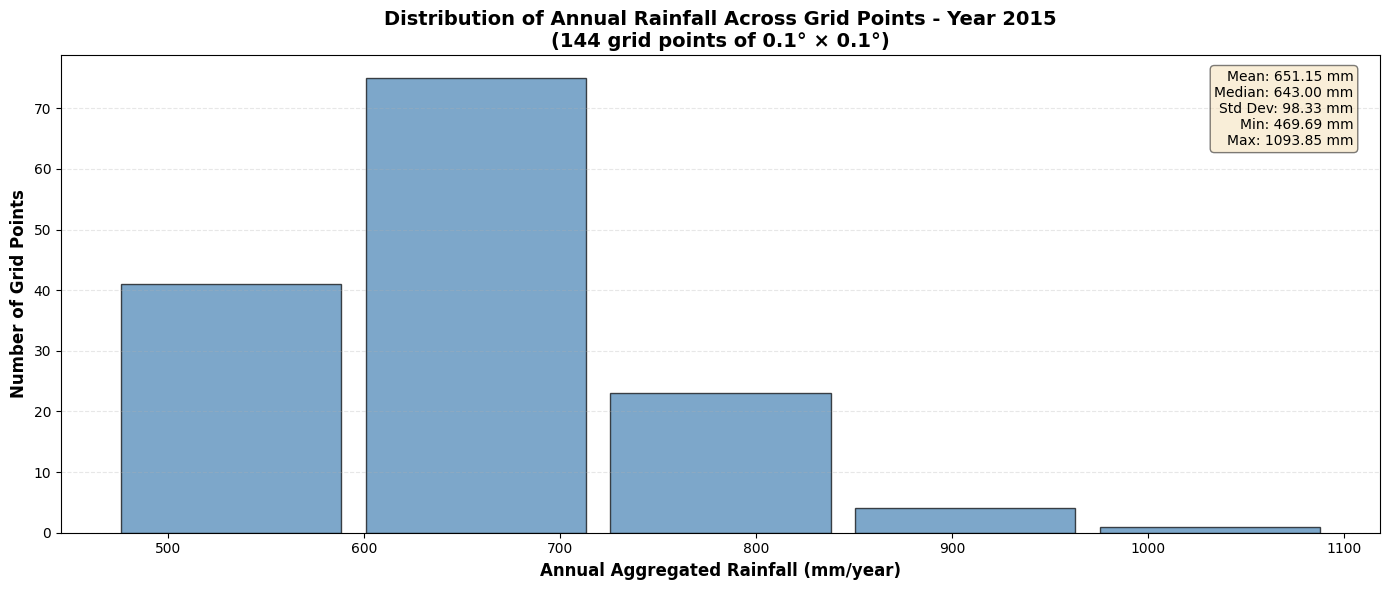


Summary Statistics for 2015:
  Mean annual rainfall: 651.15 mm
  Median annual rainfall: 643.00 mm
  Standard deviation: 98.33 mm


In [6]:
# Create histogram/bar chart
plt.figure(figsize=(14, 6))

# Create bins for the bar chart
num_bins = 5  # Adjust this for more or fewer bars
hist, bin_edges = np.histogram(annual_rainfall_valid, bins=num_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create bar chart
plt.bar(bin_centers, hist, width=(bin_edges[1] - bin_edges[0]) * 0.9, 
        edgecolor='black', alpha=0.7, color='steelblue',)

plt.xlabel('Annual Aggregated Rainfall (mm/year)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Grid Points', fontsize=12, fontweight='bold')
plt.title(f'Distribution of Annual Rainfall Across Grid Points - Year {YEAR}\n'
          f'({len(annual_rainfall_valid)} grid points of 0.1° × 0.1°)', 
          fontsize=14, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics text box
stats_text = f'Mean: {annual_rainfall_valid.mean():.2f} mm\n'
stats_text += f'Median: {np.median(annual_rainfall_valid):.2f} mm\n'
stats_text += f'Std Dev: {annual_rainfall_valid.std():.2f} mm\n'
stats_text += f'Min: {annual_rainfall_valid.min():.2f} mm\n'
stats_text += f'Max: {annual_rainfall_valid.max():.2f} mm'

plt.text(0.98, 0.97, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nSummary Statistics for {YEAR}:")
print(f"  Mean annual rainfall: {annual_rainfall_valid.mean():.2f} mm")
print(f"  Median annual rainfall: {np.median(annual_rainfall_valid):.2f} mm")
print(f"  Standard deviation: {annual_rainfall_valid.std():.2f} mm")

Computing yearly average rainfall for each grid point (2015-2025)
Years included: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Number of years: 11
Valid grid points: 144
Yearly average rainfall range: 509.57 - 923.23 mm/year
Mean yearly average: 664.57 mm/year


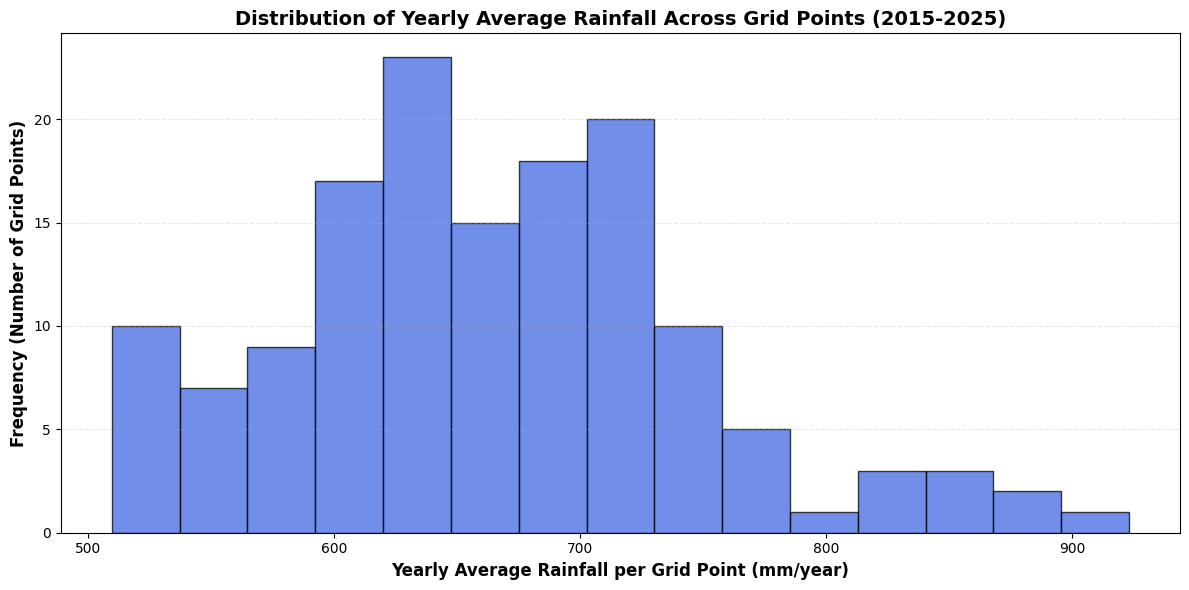

In [7]:
# Yearly average rainfall per grid point for a specified year range
from pathlib import Path
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Optional: auto-load dataset if previous cells haven't been run
# if 'nc_file' not in globals() or 'precipitation' not in globals() or 'dates' not in globals():
#     notebook_dir = Path.cwd()
#     candidate_files = [
#         notebook_dir.parent / 'GPM_IMERG_validate_final_run.nc',
#         notebook_dir.parent / 'GPM_IMERG_ludhiana_final_run.nc',
#         notebook_dir / 'GPM_IMERG_validate_final_run.nc',
#         notebook_dir / 'GPM_IMERG_ludhiana_final_run.nc',
#     ]

#     file_to_open = next((p for p in candidate_files if p.exists()), None)
#     if file_to_open is None:
#         raise FileNotFoundError('Could not find a GPM IMERG NetCDF file in expected workspace locations.')

#     nc_file = nc.Dataset(str(file_to_open), 'r')
#     time_data = nc_file.variables['date'][:]
#     precipitation = nc_file.variables['precipitation'][:]

#     dates = []
#     for i in range(time_data.shape[0]):
#         date_str = b''.join(time_data[i]).decode('utf-8')
#         dates.append(datetime.strptime(date_str, '%d-%m-%Y'))
#     dates = np.array(dates)

#     print(f'Loaded dataset from: {file_to_open}')

START_YEAR = 2015
END_YEAR = 2025

# Get years array for the full dataset
all_years = np.array([d.year for d in dates])
years_in_range = np.unique(all_years[(all_years >= START_YEAR) & (all_years <= END_YEAR)])

if len(years_in_range) == 0:
    raise ValueError(f'No complete years found between {START_YEAR} and {END_YEAR}.')

print(f'Computing yearly average rainfall for each grid point ({START_YEAR}-{END_YEAR})')
print(f'Years included: {years_in_range}')

# For each grid point, compute annual totals for each year, then average across years
lat_dim, lon_dim = precipitation.shape[1], precipitation.shape[2]
annual_totals_per_point = []  # Will store annual totals for each year

for year in years_in_range:
    year_mask = (all_years == year)
    year_data = precipitation[year_mask, :, :]
    
    # Sum daily values to get annual total for each grid point
    if np.ma.isMaskedArray(year_data):
        annual_total = np.ma.sum(year_data, axis=0)
    else:
        annual_total = np.sum(year_data, axis=0)
    
    annual_totals_per_point.append(annual_total)

# Stack annual totals: shape = (num_years, lat, lon)
annual_totals_stacked = np.ma.array(annual_totals_per_point)

# Average annual totals across years for each grid point
yearly_avg_per_point = np.ma.mean(annual_totals_stacked, axis=0)

# Flatten to 1D array
yearly_avg_flat = yearly_avg_per_point.flatten()

# Keep valid values only
if np.ma.isMaskedArray(yearly_avg_flat):
    yearly_avg_valid = yearly_avg_flat.compressed()  # Remove masked values
else:
    valid_mask = np.isfinite(yearly_avg_flat)
    if hasattr(nc_file.variables['precipitation'], '_FillValue'):
        fill_value = nc_file.variables['precipitation']._FillValue
        valid_mask &= (yearly_avg_flat != fill_value)
    yearly_avg_valid = yearly_avg_flat[valid_mask]

print(f'Number of years: {len(years_in_range)}')
print(f'Valid grid points: {len(yearly_avg_valid)}')
print(f'Yearly average rainfall range: {yearly_avg_valid.min():.2f} - {yearly_avg_valid.max():.2f} mm/year')
print(f'Mean yearly average: {yearly_avg_valid.mean():.2f} mm/year')

# Plot frequency vs yearly average rainfall
plt.figure(figsize=(12, 6))
num_bins = 15
plt.hist(yearly_avg_valid, bins=num_bins, color='royalblue', edgecolor='black', alpha=0.75)

plt.xlabel('Yearly Average Rainfall per Grid Point (mm/year)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (Number of Grid Points)', fontsize=12, fontweight='bold')
plt.title(f'Distribution of Yearly Average Rainfall Across Grid Points ({START_YEAR}-{END_YEAR})', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Classification using mean annual rainfall 

In [8]:
# Classify grid cells into bins with approximately equal number of points
# Using quantile-based binning

# Specify the number of bins/classes
NUM_BINS = 5  # Change this to your desired number of bins

# Calculate quantile-based bin edges
# This ensures approximately equal number of points in each bin
quantiles = np.linspace(0, 100, NUM_BINS + 1)
bin_edges_quantile = np.percentile(yearly_avg_valid, quantiles)

# Assign each grid cell to a bin
bin_assignments = np.digitize(yearly_avg_valid, bin_edges_quantile[1:-1])  # Results in bins 0 to NUM_BINS-1

print(f"\nClassification into {NUM_BINS} bins with approximately equal number of points:")
print("="*80)
print(f"{'Bin':<6} {'Rainfall Range (mm/year)':<35} {'Count':<10} {'Percentage':<12}")
print("="*80)

for bin_idx in range(NUM_BINS):
    bin_mask = (bin_assignments == bin_idx)
    bin_count = np.sum(bin_mask)
    bin_percentage = (bin_count / len(yearly_avg_valid)) * 100
    
    # Get actual min and max values in this bin
    bin_values = yearly_avg_valid[bin_mask]
    if len(bin_values) > 0:
        actual_min = bin_values.min()
        actual_max = bin_values.max()
        print(f"Bin {bin_idx+1:<3} [{actual_min:>7.2f} - {actual_max:>7.2f}]          {bin_count:<10} {bin_percentage:>5.1f}%")
    
print("="*80)
print(f"Total grid cells classified: {len(yearly_avg_valid)}")

# Store bin assignments for further analysis
bin_classification = pd.DataFrame({
    'grid_cell_index': np.arange(len(yearly_avg_valid)),
    'annual_avg_rainfall_mm': yearly_avg_valid,
    'bin': bin_assignments + 1  # Make bins 1-indexed for readability
})

print(f"\nBin classification dataframe created with {len(bin_classification)} grid cells.")


Classification into 5 bins with approximately equal number of points:
Bin    Rainfall Range (mm/year)            Count      Percentage  
Bin 1   [ 509.57 -  596.80]          29          20.1%
Bin 2   [ 600.68 -  639.86]          29          20.1%
Bin 3   [ 640.18 -  686.59]          28          19.4%
Bin 4   [ 686.94 -  721.48]          29          20.1%
Bin 5   [ 723.00 -  923.23]          29          20.1%
Total grid cells classified: 144

Bin classification dataframe created with 144 grid cells.


In [9]:
# Map classified grid cells back to their latitude and longitude coordinates
# and save to CSV file

# Get the 2D shape of the grid
lat_dim, lon_dim = yearly_avg_per_point.shape

# Create arrays for all lat/lon combinations
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')

# Flatten the lat/lon grids
lat_flat = lat_grid.flatten()
lon_flat = lon_grid.flatten()

# Recreate the same mask logic used to create yearly_avg_valid
yearly_avg_flat_full = yearly_avg_per_point.flatten()

if np.ma.isMaskedArray(yearly_avg_flat_full):
    # For masked arrays, if the mask is a single boolean (False or True), assume all are valid/invalid
    # This happens when the mask is "shrunk" (nomask) or just a single value
    if np.shape(yearly_avg_flat_full.mask) == ():
        if yearly_avg_flat_full.mask: # If mask is True (invalid)
             valid_indices = np.zeros_like(yearly_avg_flat_full, dtype=bool)
        else: # If mask is False (valid)
             valid_indices = np.ones_like(yearly_avg_flat_full, dtype=bool)
    else:
        valid_indices = ~yearly_avg_flat_full.mask
        
    # Also flatten it to ensure proper shape
    if hasattr(valid_indices, 'flatten'):
        valid_indices = valid_indices.flatten()
else:
    valid_mask = np.isfinite(yearly_avg_flat_full)
    if hasattr(nc_file.variables['precipitation'], '_FillValue'):
        fill_value = nc_file.variables['precipitation']._FillValue
        valid_mask &= (yearly_avg_flat_full != fill_value)
    valid_indices = valid_mask

# Extract lat/lon for valid grid cells only
lat_valid = lat_flat[valid_indices]
lon_valid = lon_flat[valid_indices]

# Verify lengths match
print(f"Debug: lat_valid length: {len(lat_valid)}, bin_classification length: {len(bin_classification)}")
assert len(lat_valid) == len(bin_classification), f"Length mismatch: {len(lat_valid)} vs {len(bin_classification)}"

# Add latitude and longitude to the classification dataframe
bin_classification['latitude'] = lat_valid
bin_classification['longitude'] = lon_valid

# Reorder columns for better readability
bin_classification = bin_classification[['latitude', 'longitude', 'annual_avg_rainfall_mm', 'bin', 'grid_cell_index']]

# Save to CSV file
output_filename = f'rainfall_classification_{NUM_BINS}_bins_validate.csv' #rainfall_classification_5_bins_validate.csv
bin_classification.to_csv(output_filename, index=False)

print(f"\n{'='*80}")
print(f"Classification saved to: {output_filename}")
print(f"Total records: {len(bin_classification)}")
print(f"{'='*80}")
print("\nFirst few records:")
print(bin_classification.head(10).to_string(index=False))
print(f"\n{'='*80}")

Debug: lat_valid length: 144, bin_classification length: 144

Classification saved to: rainfall_classification_5_bins_validate.csv
Total records: 144

First few records:
 latitude  longitude  annual_avg_rainfall_mm  bin  grid_cell_index
29.950001  74.949997              509.573639    1                0
29.950001  75.050003              515.600952    1                1
29.950001  75.150002              521.664978    1                2
29.950001  75.250000              537.412659    1                3
29.950001  75.349998              573.346802    1                4
29.950001  75.449997              617.907715    2                5
29.950001  75.550003              593.241272    1                6
29.950001  75.650002              603.882751    2                7
29.950001  75.750000              629.535889    2                8
29.950001  75.849998              657.930908    3                9



In [10]:
# Display sample grid cells from each bin
print("\nSample grid cells from each bin:")
print("="*80)

for bin_idx in range(NUM_BINS):
    bin_data = bin_classification[bin_classification['bin'] == bin_idx + 1]
    print(f"\nBin {bin_idx + 1}: {len(bin_data)} grid cells")
    print(f"  Range: {bin_data['annual_avg_rainfall_mm'].min():.2f} - {bin_data['annual_avg_rainfall_mm'].max():.2f} mm/year")
    print(f"  Mean: {bin_data['annual_avg_rainfall_mm'].mean():.2f} mm/year")
    print(f"  Sample (first 5):")
    print(bin_data.head().to_string(index=False))

print("="*80)


Sample grid cells from each bin:

Bin 1: 29 grid cells
  Range: 509.57 - 596.80 mm/year
  Mean: 553.71 mm/year
  Sample (first 5):
 latitude  longitude  annual_avg_rainfall_mm  bin  grid_cell_index
29.950001  74.949997              509.573639    1                0
29.950001  75.050003              515.600952    1                1
29.950001  75.150002              521.664978    1                2
29.950001  75.250000              537.412659    1                3
29.950001  75.349998              573.346802    1                4

Bin 2: 29 grid cells
  Range: 600.68 - 639.86 mm/year
  Mean: 620.88 mm/year
  Sample (first 5):
 latitude  longitude  annual_avg_rainfall_mm  bin  grid_cell_index
29.950001  75.449997              617.907715    2                5
29.950001  75.650002              603.882751    2                7
29.950001  75.750000              629.535889    2                8
30.049999  75.449997              615.238647    2               17
30.049999  75.650002             

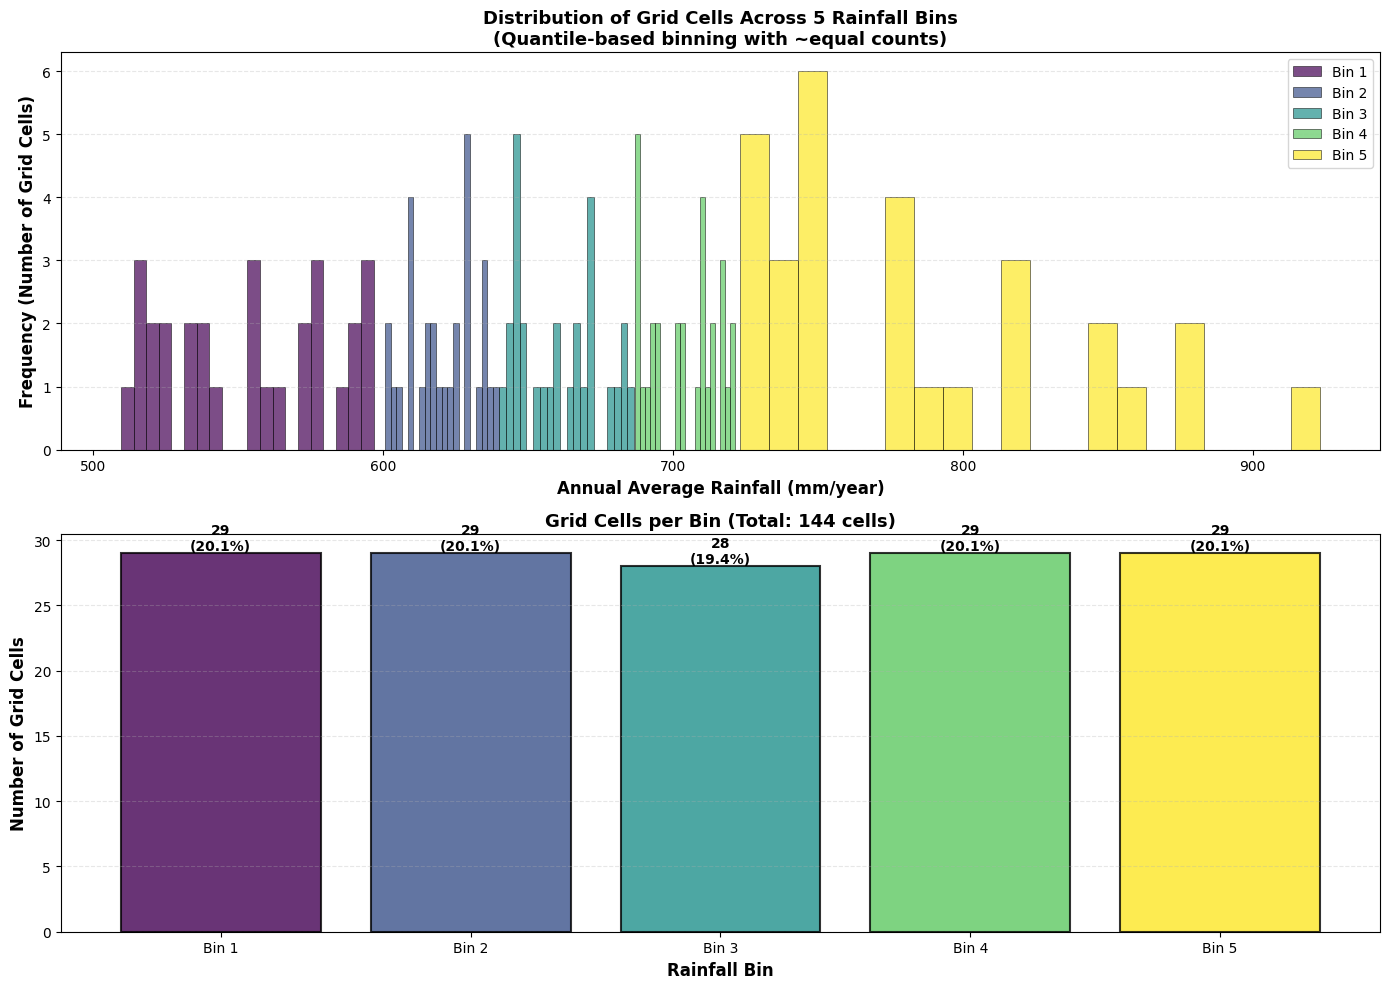


Visualization complete for 5 bins with approximately equal distribution.


In [11]:
# Visualize the bin classification
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Histogram colored by bins
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, NUM_BINS))

for bin_idx in range(NUM_BINS):
    bin_mask = (bin_assignments == bin_idx)
    bin_values = yearly_avg_valid[bin_mask]
    
    ax1.hist(bin_values, bins=20, alpha=0.7, label=f'Bin {bin_idx+1}', 
             color=colors[bin_idx], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Annual Average Rainfall (mm/year)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency (Number of Grid Cells)', fontsize=12, fontweight='bold')
ax1.set_title(f'Distribution of Grid Cells Across {NUM_BINS} Rainfall Bins\n(Quantile-based binning with ~equal counts)', 
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Bar chart showing count per bin
ax2 = axes[1]
bin_counts = [np.sum(bin_assignments == i) for i in range(NUM_BINS)]
bin_labels = [f'Bin {i+1}' for i in range(NUM_BINS)]

bars = ax2.bar(bin_labels, bin_counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add count labels on top of bars
for bar, count in zip(bars, bin_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}\n({count/len(yearly_avg_valid)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Rainfall Bin', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Grid Cells', fontsize=12, fontweight='bold')
ax2.set_title(f'Grid Cells per Bin (Total: {len(yearly_avg_valid)} cells)', 
              fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nVisualization complete for {NUM_BINS} bins with approximately equal distribution.")

## Spatial Distribution of Rainfall Classes

Scatter plot of grid-cell locations coloured by their assigned rainfall bin.


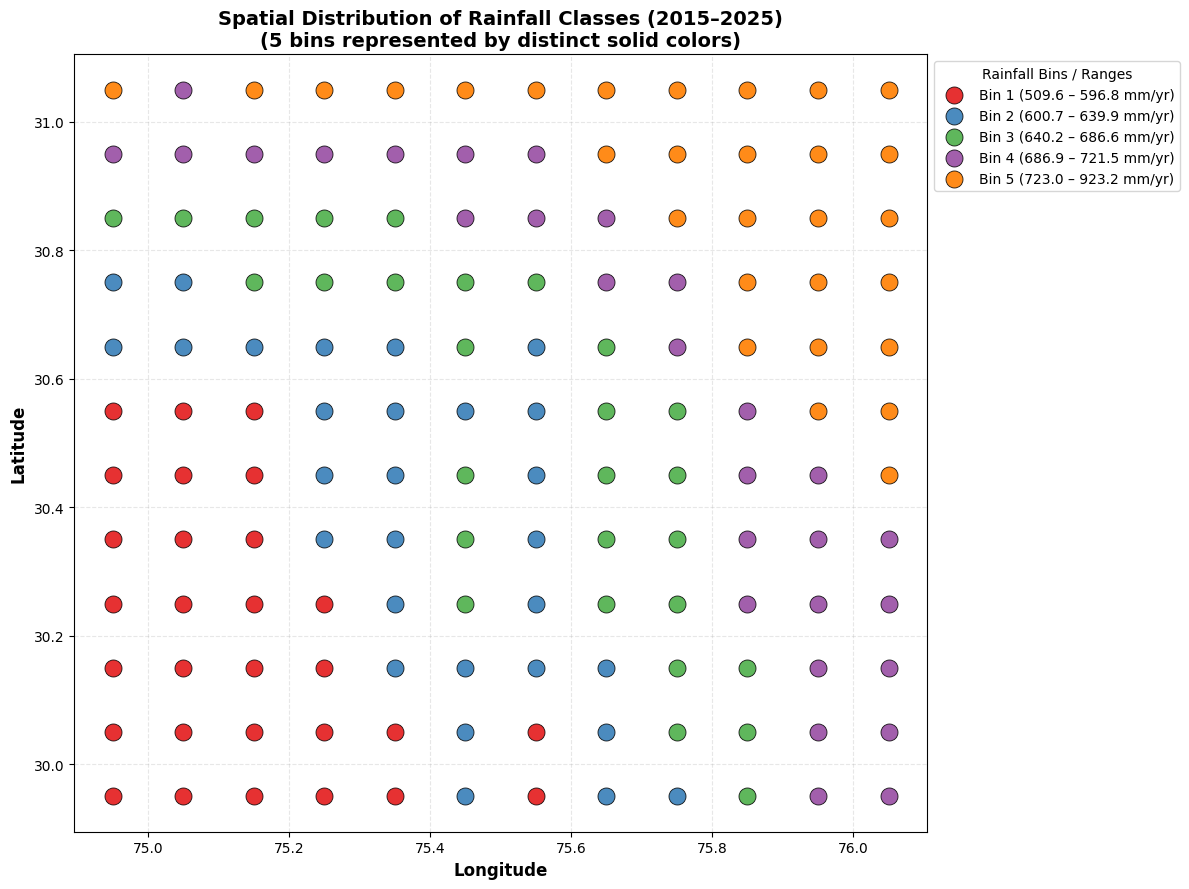

In [12]:

# Spatial scatter plot: grid cell locations coloured by rainfall bin
# Using solid distinct colors instead of a continuous colormap
import matplotlib.colors as mcolors

# Set of distinct qualitative colors
distinct_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf', '#999999']

fig, ax = plt.subplots(figsize=(12, 9))

# Plot each bin separately to assign solid colors and build a custom legend
for i in range(1, NUM_BINS + 1):
    bin_subset = bin_classification[bin_classification['bin'] == i]
    if bin_subset.empty:
        continue
    
    # Calculate range for the legend label
    lo = bin_subset['annual_avg_rainfall_mm'].min()
    hi = bin_subset['annual_avg_rainfall_mm'].max()
    
    ax.scatter(
        bin_subset['longitude'],
        bin_subset['latitude'],
        color=distinct_colors[(i-1) % len(distinct_colors)],
        label=f'Bin {i} ({lo:.1f} – {hi:.1f} mm/yr)',
        s=150, 
        edgecolors='black', 
        linewidths=0.6, 
        alpha=0.9
    )

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title(
    f'Spatial Distribution of Rainfall Classes ({START_YEAR}–{END_YEAR})\n'
    f'({NUM_BINS} bins represented by distinct solid colors)',
    fontsize=14, fontweight='bold'
)

# Place legend outside of the plot for clarity
ax.legend(title='Rainfall Bins / Ranges', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


In [13]:
# Display max and min annual average rainfall across all grid cells
max_annual_avg_rainfall = yearly_avg_valid.max()
min_annual_avg_rainfall = yearly_avg_valid.min()

print("="*60)
print("ANNUAL AVERAGE RAINFALL STATISTICS")
print("="*60)
print(f"Maximum annual average rainfall: {max_annual_avg_rainfall:.2f} mm/year")
print(f"Minimum annual average rainfall: {min_annual_avg_rainfall:.2f} mm/year")
print(f"Range: {max_annual_avg_rainfall - min_annual_avg_rainfall:.2f} mm/year")
print(f"Total number of valid grid cells: {len(yearly_avg_valid)}")
print("="*60)

ANNUAL AVERAGE RAINFALL STATISTICS
Maximum annual average rainfall: 923.23 mm/year
Minimum annual average rainfall: 509.57 mm/year
Range: 413.65 mm/year
Total number of valid grid cells: 144


## Classification of Grid Cells into Bins

This section classifies grid cells into a specified number of bins based on annual average rainfall, with approximately equal numbers of points in each bin (quantile-based binning).

In [14]:
# # Yearly aggregation: average annual rainfall per grid cell over the full duration

# # Use available date and precipitation arrays from earlier cells
# if 'dates' not in globals() or 'precipitation' not in globals():
#     raise RuntimeError("Run the data loading cells first so 'dates' and 'precipitation' are available.")

# all_years = np.array([d.year for d in dates])
# unique_years = np.unique(all_years)

# yearly_avg_per_cell = []

# for year in unique_years:
#     year_mask = (all_years == year)
#     yearly_data = precipitation[year_mask, :, :]  # daily -> yearly for each cell

#     # Aggregate to yearly rainfall per grid cell (sum over days)
#     yearly_total_per_cell = np.ma.sum(yearly_data, axis=0)

#     # Spatial average across all valid grid cells for that year
#     if np.ma.isMaskedArray(yearly_total_per_cell):
#         yearly_mean = float(np.ma.mean(yearly_total_per_cell))
#     else:
#         yearly_mean = float(np.mean(yearly_total_per_cell))

#     yearly_avg_per_cell.append(yearly_mean)

# yearly_avg_per_cell = np.array(yearly_avg_per_cell)

# plt.figure(figsize=(12, 6))
# plt.plot(unique_years, yearly_avg_per_cell, marker='o', linewidth=2, color='teal')
# plt.xlabel('Year', fontsize=12, fontweight='bold')
# plt.ylabel('Average Annual Rainfall per Grid Cell (mm/year)', fontsize=12, fontweight='bold')
# plt.title('Yearly Average Rainfall per Grid Cell (Full Duration)', fontsize=14, fontweight='bold')
# plt.grid(alpha=0.3, linestyle='--')
# plt.tight_layout()
# plt.show()

# yearly_summary = pd.DataFrame({
#     'year': unique_years,
#     'avg_annual_rainfall_per_grid_cell_mm': yearly_avg_per_cell
# })

# print(yearly_summary)
# print(f"\nOverall period mean: {yearly_avg_per_cell.mean():.2f} mm/year")

In [15]:
# Close the NetCDF file
nc_file.close()
print("NetCDF file closed.")

NetCDF file closed.
